This file contains the user submission for assignment 2 of the Pyhton for business course. 


Task 0, a

For the course project i planon using the data set called Airbnb Market Data: Europe 373 Cities, available here: https://www.kaggle.com/datasets/jasonairroi/airbnb-market-data-europe



Task 0, b
The data set contains data on AirBnB listings. The data set contains 61 columns and 95894 rows. 

The dataset contains following variables: 


Descriptive:

listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,bedrooms,beds,baths,registration,amenities,instant_book,professional_management,min_nights,cancellation_policy,currency,cleaning_fee,extra_guest_fee,num_reviews,rating_overall,rating_accuracy,rating_checkin,rating_cleanliness,rating_communication,rating_location,rating_value,

Performannce Trailing Twelwe Months(TTM):

ttm_revenue,ttm_revenue_native,ttm_avg_rate,ttm_avg_rate_native,ttm_occupancy,ttm_adjusted_occupancy,ttm_revpar,ttm_revpar_native,ttm_adjusted_revpar,ttm_adjusted_revpar_native,ttm_reserved_days,ttm_blocked_days,ttm_available_days,ttm_total_days

Performance Last 90 days(l90d):

l90d_revenue,l90d_revenue_native,l90d_avg_rate,l90d_avg_rate_native,l90d_occupancy,l90d_adjusted_occupancy,l90d_revpar,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,

Location:

country, state, city

The plan for the project is to quantitatively analyze the effect of superhost status on occupancy rates and revenue. Using the TTM performance metrics.

Task 0, c 

Importing data to the notebook

In [21]:
import pandas as pd

df = pd.read_csv("listings_clean.csv", low_memory=False)
print(df.shape)
df.head()

(95418, 61)


,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city
0,121902,Entire home,entire_home,https://a0.muscache.com/im/pictures/77c0e3a9-0...,77.0,fe453949b595,false,37.0758,27.2426,6.0,...,0.0,0.0,0.0,0.0,90.0,90.0,90.0,Turkey,Muğla,Bodrum
1,805342,Entire condo,entire_home,https://a0.muscache.com/im/pictures/11494599/4...,16.0,59711ec4c245,false,37.0092,27.2563,3.0,...,0.0,0.0,0.0,0.0,0.0,90.0,90.0,Turkey,Muğla,Bodrum
2,805361,Entire home,entire_home,https://a0.muscache.com/im/pictures/bda48dbc-d...,34.0,d217bf6e3427,false,37.0292,27.4410,5.0,...,0.0,0.0,0.0,0.0,0.0,90.0,90.0,Turkey,Muğla,Bodrum
3,853827,Entire villa,entire_home,https://a0.muscache.com/im/pictures/26626113/a...,70.0,605fc7d80e02,false,37.0434,27.2517,16.0,...,536.3,0.0,0.0,2.0,0.0,88.0,90.0,Turkey,Muğla,Bodrum
4,967193,Entire villa,entire_home,https://a0.muscache.com/im/pictures/68107669/2...,37.0,3b963e8cd040,false,37.0429,27.3898,4.0,...,0.0,0.0,0.0,0.0,0.0,90.0,90.0,Turkey,Muğla,Bodrum


Dropping the unnecessary last 90 days statistic. 

In [22]:
cols_to_drop = [col for col in df.columns if 'l90d' in col]
print("Columns dropped:", len(cols_to_drop))
df = df.drop(columns=cols_to_drop)

Columns dropped: 14


Summary statistics

In [25]:
df.describe()


,photos_count,latitude,longitude,guests,bedrooms,beds,cleaning_fee,extra_guest_fee,num_reviews,rating_overall,...,ttm_occupancy,ttm_adjusted_occupancy,ttm_revpar,ttm_revpar_native,ttm_adjusted_revpar,ttm_adjusted_revpar_native,ttm_reserved_days,ttm_blocked_days,ttm_available_days,ttm_total_days
count,9.462200e+04,94849.000000,94849.000000,84462.000000,78103.000000,93859.000000,92865.000000,91575.000000,94766.000000,92247.000000,...,94849.000000,94849.000000,94849.000000,94849.000000,94849.000000,94849.000000,94849.000000,94849.000000,94849.000000,94849.000000
mean,7.065491e+03,44.345640,6.494236,4.406408,1.923486,2.736626,47.262467,1.954606,115.825256,4.766968,...,0.312764,0.267865,48.900426,251.471328,42.172773,178.310835,114.157587,57.369693,250.842223,365.134277
std,1.292128e+06,8.076288,12.870159,2.375725,1.185518,2.029569,108.392324,8.743453,147.346999,0.206994,...,0.222456,0.555101,61.457716,2076.032090,68.334957,1426.921086,81.193190,68.347673,81.192834,29.328278
min,0.000000e+00,-21.108200,-63.151500,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.600000,...,0.000000,0.000000,0.300000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,339.000000
25%,1.500000e+01,40.258000,-1.236700,3.000000,1.000000,1.000000,0.000000,0.000000,24.000000,4.680000,...,0.126000,0.000000,14.300000,17.400000,0.000000,0.000000,46.000000,0.000000,195.000000,365.000000
50%,2.300000e+01,43.775200,5.718600,4.000000,2.000000,2.000000,23.000000,0.000000,63.000000,4.820000,...,0.263000,0.185000,31.500000,38.400000,21.400000,24.800000,96.000000,31.000000,269.000000,365.000000
75%,3.400000e+01,49.443900,14.513800,6.000000,2.000000,4.000000,58.000000,0.000000,148.000000,4.910000,...,0.466000,0.470000,60.900000,85.800000,56.500000,68.700000,170.000000,94.000000,319.000000,365.000000
max,2.939731e+08,69.950800,55.342000,16.000000,41.000000,60.000000,9608.000000,553.000000,3784.000000,5.000000,...,0.997000,125.900000,1808.100000,262008.600000,2869.300000,154617.300000,364.000000,355.000000,365.000000,8102.000000


Visualisation 1, ttm average rate and ttm occupancy rate as scatterplot as logarithms

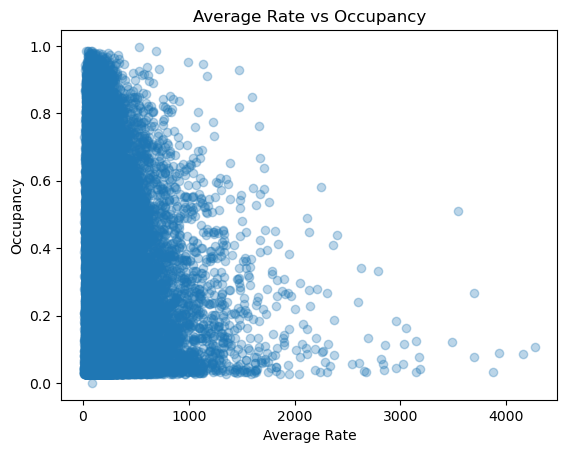

In [30]:
import matplotlib.pyplot as plt

plt.scatter(df['ttm_avg_rate'], df['ttm_occupancy'], alpha=0.3)
plt.xlabel("Average Rate")
plt.ylabel("Occupancy")
plt.title("Average Rate vs Occupancy")
plt.show()

Visulaisation 2, box plot of bedrooms and Average rate

<Figure size 800x500 with 0 Axes>

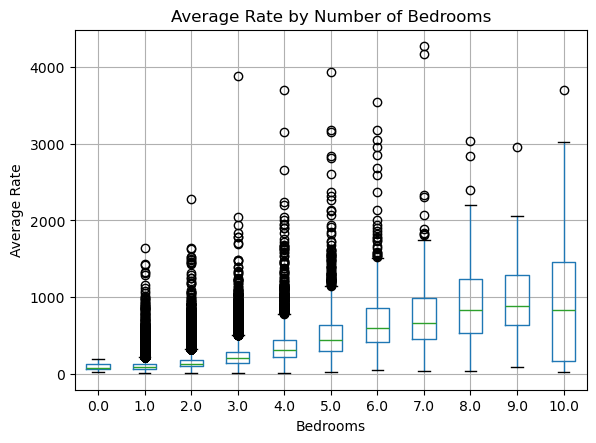

In [29]:


df_plot = df[df['bedrooms'] <= 10]  # remove extreme outliers

plt.figure(figsize=(8,5))
df_plot.boxplot(column='ttm_avg_rate', by='bedrooms')
plt.title("Average Rate by Number of Bedrooms")
plt.suptitle("")
plt.xlabel("Bedrooms")
plt.ylabel("Average Rate")
plt.show()

Task 1, a
